# Regression

### Motivation

- Regression models are simple.
- Answers questions like:

    - Is there a relationship between variables?
    - How strong is this relationship?
    - Which parameter influences most?
    - can we predict the outcome?

### Definition:

> &nbsp;  
> In statistical modeling, `regression analysis` is a set of statistical processes for  
> estimating the relationships between a dependent variable ('outcome', 'response', '`label`') and  
> one or more independent variables ('predictors', 'covariates', '`features`').
> <br><br>

<span style="font-size: 70%">Source: <a href="https://en.wikipedia.org/wiki/Regression_analysis">Wikipedia</a></span>


<img src="./img/4_linear_regression_error_term.png" width="500px"><br>
<span style="font-size: 70%">Linear regression tries to reduce the total error e by optimizing parameters b0 and b1.<br>The regression line is the result of this optimization.</span>

##### Mathematically:

$Y_i = f\left( X_{i,j}, \beta_j \right) + e_i$

The goal is to find a function $f$ that best fits the data ($X_{i,j}$) by changing parameters $\beta_j$ to minimizing the error $e_i$.
<br><br>

### Example

Assume you need to decide whether placing advertisements is feasible.

You have records of previous placements in these channels:

- TV (k €)
- Radio (k €)
- Newspapers (k €)
- Total sales (M €)

in tabular form.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit Learn provides tailored models for data science and machine learning
from sklearn.linear_model import LinearRegression

In [2]:
# get the data
data = pd.read_csv('data/Advertising.csv', index_col=0)
data.head()

,TV,radio,newspaper,sales
idx,,,,
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
# get the magic 8
data.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


##### Interpreting the numbers

We have a total of 200 records comparing sales to ad placements (line `count`).

Spending on TV channles are 3x as much as the other two channels  (line `mean`).

Let's inspect this visually.

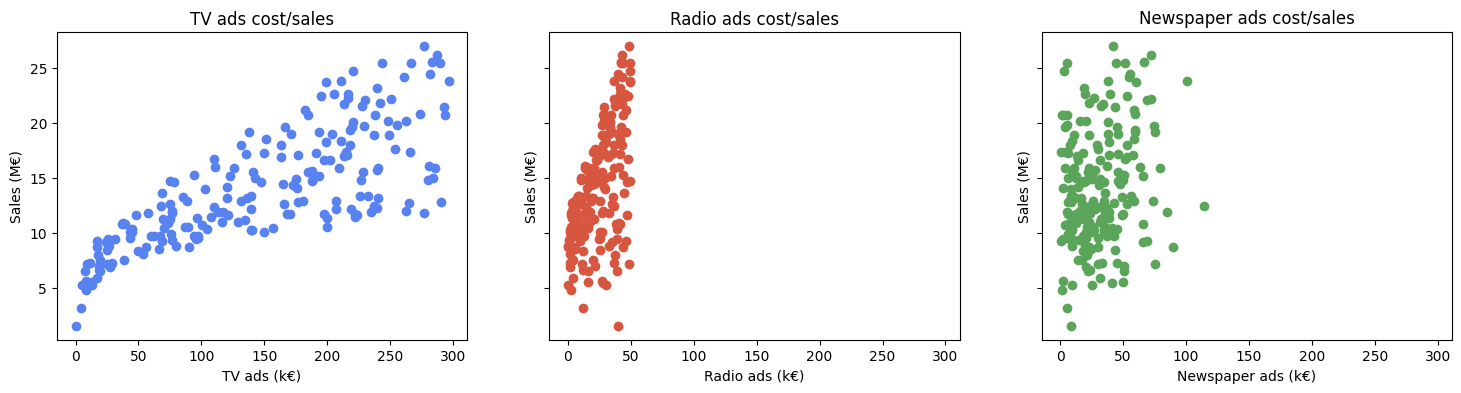

In [4]:
# plot the data

fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)

axs[0].scatter(data['TV'], data['sales'], c='#5882ef')
axs[0].set_title("TV ads cost/sales")
axs[0].set_xlabel('TV ads (k€)')
axs[0].set_ylabel('Sales (M€)')

axs[1].scatter(data['radio'], data['sales'], c='#d6563f')
axs[1].set_title("Radio ads cost/sales")
axs[1].set_xlabel('Radio ads (k€)')
axs[1].set_ylabel('Sales (M€)')

axs[2].scatter(data['newspaper'], data['sales'], c='#5aa559')
axs[2].set_title("Newspaper ads cost/sales")
axs[2].set_xlabel('Newspaper ads (k€)')
axs[2].set_ylabel('Sales (M€)')

plt.show()


TV ads are the most expensive, radio ads the cheapest.

Can we find a formular that allows us to predict sales depending on advertisment cost?

In [5]:
# compare TV vs Radio

# prepare the data
X_tv = data['TV'].values.reshape(-1, 1)
X_radio = data['radio'].values.reshape(-1, 1)
y = data['sales'].values.reshape(-1, 1)

# create the models
reg_tv = LinearRegression()
reg_radio = LinearRegression()

# train (fit) the models
reg_tv.fit(X_tv, y)
reg_radio.fit(X_radio, y)

print(
    f"The linear models are: \n"
    f"  Y_tv    = {reg_tv.intercept_[0]:2.2} + {reg_tv.coef_[0][0]:2.3} * €/ads (TV) \n"
    f"  Y_radio = {reg_radio.intercept_[0]:2.2} + {reg_radio.coef_[0][0]:2.3} * €/ads (Radio)")


The linear models are: 
  Y_tv    = 7.0 + 0.0475 * €/ads (TV) 
  Y_radio = 9.3 + 0.202 * €/ads (Radio)


In [6]:
# we can predict approximated sales based on ad expenditure

pred_tv = reg_tv.predict(X_tv)
pred_radio = reg_radio.predict(X_radio)

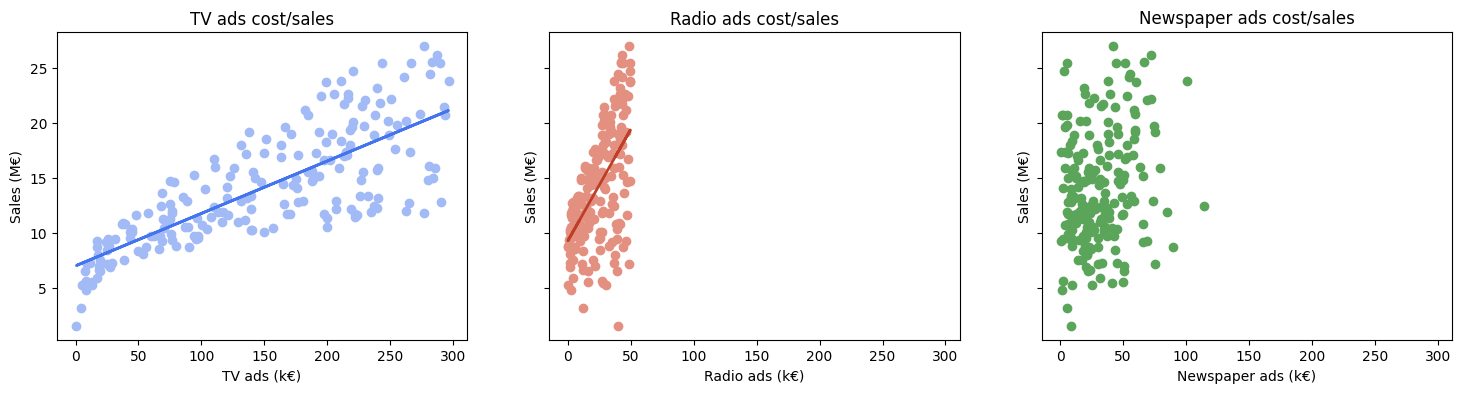

In [7]:
# plot the data

fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)

axs[0].scatter(data['TV'], data['sales'], c='#a2baf6')
axs[0].plot(X_tv, pred_tv, linewidth=2, c='#4474ee')
axs[0].set_title("TV ads cost/sales")
axs[0].set_xlabel('TV ads (k€)')
axs[0].set_ylabel('Sales (M€)')

axs[1].scatter(data['radio'], data['sales'], c='#e49081')
axs[1].plot(X_radio, pred_radio, linewidth=2, c='#bd3f28')
axs[1].set_title("Radio ads cost/sales")
axs[1].set_xlabel('Radio ads (k€)')
axs[1].set_ylabel('Sales (M€)')

axs[2].scatter(data['newspaper'], data['sales'], c='#5aa559')
axs[2].set_title("Newspaper ads cost/sales")
axs[2].set_xlabel('Newspaper ads (k€)')
axs[2].set_ylabel('Sales (M€)')

plt.show()


<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task:</h5>Discuss the results and give an interpretation.</td>
</tr>
</table>

##### Conclusion

Marginal sales (no investment in ads) for TV is € 7M, on radio it's € 9,3M.

Investing in radio ads has a better __price/performance ratio__ (202) than TV (47,5).

Placing ads in newspapers does not give enough indication of dependencies.
<br><br>

Let's do some maths

# Regression models

So far, we have covered linear regression in one variable (feature). This can be generalized.

We need to find an expected value $E(y|x)$ that is simple to model but estimates well enough.

##### Constant Model:
__M1__: $E(y|x) = \theta$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (with $E(y|x)$ is independent from x)
##### Linear Model:
__M2__: $E(y|x) = \theta_0 + \theta_1x + \epsilon$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (M1 equals M2 with $\theta_1 = 0$)
##### Squared Model:
__M3__: $E(y|x) = \theta_0 + b{x^2} + \epsilon$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (M2 with $z = x^2$)
##### Exponential Model:
__M4__: $E(y|x) = \theta_0 + b^x + \epsilon$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (none-linear model)
##### Polynomial Model:
__M5__: $E(y|x) = \theta_0 + \theta_1 x + \theta_2 x^2 + ... + \theta_n x^n + \epsilon = \sum_{i=0}^n \theta_i x^i + \epsilon$

<br>
While suitable for educational purposes, single feature models are not realistic.
<br><br>


# Multivariate Linear Regression

More realistically we will have a given feature vector:

$X = \left ( x_1, x_2, ...  , x_n \right )$ 

Data:

$Y_i = \theta_0 + \sum_{k=1}^{m} \theta_k \cdot X_{ik} + \epsilon_i$
<br>

Hypothesis:

$h_\theta (x) = \theta_0 + \theta_1 \cdot x_1 + \theta_2 \cdot x_2 + ... + \theta_n \cdot x_n$
<br><br>

This can be written as

$h_\theta (x) = \left[ \theta_0,  \theta_1,  ... \theta_n \right] \times \begin{vmatrix} \color{red}x_0 \color{#808080} \\ x_1 \\ ... \\ x_n \end{vmatrix} = \theta^T \times X $ &nbsp;&nbsp; ... with $\color{red}x_0 = 1$  

or

with $X = \begin{vmatrix} x_0^{(1)} & x_1^{(1)} \\ x_0^{(2)} & x_1^{(2)} \\ x_0^{(3)} & x_1^{(3)} \end{vmatrix} $ , &nbsp;&nbsp; $ \theta = \begin{vmatrix} \theta_0 \\ \theta_1 \end{vmatrix}$ 

##### $ \to $ Vectorized hypothesis

> &nbsp;  
> $h_\theta (X) = X \cdot \theta $
> <br><br>

<br><br>

Taking a multivariate cost funktion:

$ J \left( \theta \right) = \frac {1}{2 \cdot m} { \sum_{i=1}^{m}  \left ( h_\theta \left ( x^{(i)} \right ) - y^{(i)} \right ) } ^2 $

gives

##### $ \to $ Vectorized cost function

> &nbsp;  
> $ J \left ( \theta \right) = \frac {1}{2 \cdot m} \left( X \cdot \theta - \overrightarrow{y} \right)^T \left( X \cdot \theta - \overrightarrow{y} \right) $ , 
&nbsp;&nbsp; ... with $ \overrightarrow{y} = \begin{vmatrix} y_1 \\ y_2 \\ ... \\ y_n \end{vmatrix} $
> <br><br>

<br><br>

Gradient descent:

$ \theta_j = \theta_j - \alpha \cdot \frac{1}{m} \cdot \sum_{i=1}^{m} \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) \cdot x_j^{(i)} $  , 
&nbsp;&nbsp; ... for $ j:= 0 ... n $

##### $ \to $ Vectorized gradient descent

> &nbsp;  
> $ \theta = \theta - \alpha \nabla J\left( \theta \right) $ , 
&nbsp;&nbsp; ... with $ \nabla J\left( \theta \right) ... \begin{vmatrix} \frac{\partial J\left ( \theta \right )}{\partial \theta_0} \\ \\ \frac{\partial J\left ( \theta \right )}{\partial \theta_1} \\ \\ ... \\ \\ \frac{\partial J\left ( \theta \right )}{\partial \theta_n} \end{vmatrix} $
> <br><br>

<br><br>

Putting it all together

$ \theta_j = \theta_j - \alpha \cdot \frac{1}{m} \cdot \sum_{i=1}^{m} \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) \cdot x_j^{(i)} $  , 
&nbsp;&nbsp; ... for $ j:= 0 ... n $

<br>

$ \theta = \theta - \alpha \nabla J\left( \theta \right) $ , 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  $ \nabla J\left( \theta \right) ... \begin{vmatrix} \color{green} { \frac{\partial J\left ( \theta \right )}{\partial \theta_0} } \\ \\ \frac{\partial J\left ( \theta \right )}{\partial \theta_1} \\ \\ ... \\ \\ \frac{\partial J\left ( \theta \right )}{\partial \theta_n} \end{vmatrix} $

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
$ \color{green} {\frac{\partial J\left ( \theta \right )}{\partial \theta_j}} \color{#787878} { = \frac{1}{m} \cdot \sum_{i=1}^{m} \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) \cdot x_j^{(i)} } $

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
$ = \frac{1}{m} \cdot \sum_{i=1}^{m} x_j^{(i)} \cdot \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) $

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
$ = \color{blue} { \frac{1}{m} \cdot {\overrightarrow x_j}^T \cdot \left( X \cdot \theta - \overrightarrow y \right) } $

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;
$ \nabla J\left ( \theta \right ) $ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 
$ = \color{blue} { \frac{1}{m} \cdot X^T \cdot \left( X \cdot \theta - \overrightarrow y \right) } $

Vectorized gradient descent

$ \theta = \theta - \frac{\alpha}{\color{blue}{m}} \color{blue} { \cdot X^T \cdot \left( X \cdot \theta - \overrightarrow y \right) } $

(can easily be calculated with `NumPy`)

<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task:</h5>Discuss: Can this model evaluate quadratic or cubic functions? How?<br>Where would this apply?</td>
</tr>
</table>